## 1. Problem Definition

The **Capacitated Vehicle Routing Problem (CVRP)** is a classic combinatorial optimization problem:

- **Objective:** Minimize total travel distance while delivering goods to customers.
- **Constraints:**
  - Each vehicle has a limited capacity (weight or volume).
  - Each customer has a demand that must be fulfilled in a single visit.
  - All routes start and end at a central depot.
- **Decision Variables:** Assignment of customers to vehicles and the order of visits within each route.

CVRP is **NP-hard**, meaning exact algorithms become impractical for large instances. Therefore, **metaheuristics** are essential.

## 2. Metaheuristics Implemented

### 2.1 Clarke & Wright Savings Heuristic (C&W)

**Purpose:** Fast, greedy construction heuristic.

**How it works:**
1. Start with each customer in a separate route: (depot → customer → depot).
2. Compute savings S(i,j) = c(i,0) + c(0,j) - c(i,j) for all pairs of customers.
   - Savings measure how much distance we save by linking two routes.
3. Sort savings in **descending order**.
4. Greedily merge routes if:
   - Both customers are at the **ends** of their respective routes.
   - The merged route respects the **vehicle capacity**.

**Time Complexity:** O(n² log n)  
**Quality:** Produces a reasonable solution quickly (typically 3–10% gap from optimum on benchmark instances).

---

### 2.2 Tabu Search (TS)

**Purpose:** Local search with memory to escape local optima.

**How it works:**
1. Start from an initial solution (e.g., C&W).
2. At each iteration, examine a **neighborhood** of solutions (e.g., swap customers, 2-opt moves).
3. Move to the **best neighbor**, even if it worsens the objective (to escape local optima).
4. Maintain a **tabu list** (forbidden moves for T iterations) to prevent cycling.
5. Allow an **aspiration criterion** to override the tabu list if a move leads to a new global best.

**Key Parameters:**
- `tabu_size`: length of tabu list (typically √n).
- `max_iter`: maximum iterations.
- `neighborhood`: type of moves (swap, 2-opt, relocate).

**Advantage:** Can escape local optima by accepting worse moves temporarily.  
**Disadvantage:** Tuning is problem-dependent.

---

### 2.3 Ant Colony Optimization (ACO) with C&W Seeding

**Purpose:** Population-based metaheuristic inspired by ant pheromone behavior.

**How it works:**
1. **Initialize pheromone matrix** with small uniform values; optionally seed with C&W edges.
2. **For each iteration:**
   - Each of m ants constructs a solution independently:
     - Start at depot; greedily select next customer based on:
       - **Pheromone τ(i,j)**: collective memory (high if many ants used this edge).
       - **Visibility η(i,j) = 1/d(i,j)**: heuristic (closer is better).
       - **Probability** ∝ τ(i,j)^α × η(i,j)^β (balance between memory and heuristic).
   - Respect vehicle capacity constraints.
   - Use **local search** (2-opt, relocate) to improve solution.
3. **Update pheromone:**
   - **Evaporate:** τ ← (1 - ρ) × τ (forget old paths).
   - **Deposit:** Add pheromone on edges of the best solution found.
4. **Track global best** and return the best solution found.

**C&W Seeding Enhancement:**
- Initialize pheromone on C&W edges with a high value (`seed_strength`).
- Guides ants toward the good initial solution while still exploring.

**Key Parameters:**
- `alpha` (α): influence of pheromone (typical: 1–3).
- `beta` (β): influence of visibility (typical: 2–4).
- `rho` (ρ): evaporation rate (typical: 0.1–0.3).
- `seed_strength`: initial pheromone on C&W edges.
- `num_ants`, `max_iter`: population size and iterations.

**Advantage:** Balances exploration (new edges) and exploitation (proven good edges).  
**Disadvantage:** More parameters to tune; requires more computation than C&W alone.

---

### 2.4 Hybrid Strategy

**Combined approach used in this project:**
1. **C&W** → fast initial solution.
2. **ACO with C&W seeding** → iterative improvement guided by the initial solution.
3. **Local search (2-opt, relocate)** → polish each ant's solution.
4. **Fallback guarantee:** If ACO does not beat C&W, return C&W (no degradation).

**Benefits:**
- Fast startup with C&W.
- Guided exploration with ACO seeding.
- Fine-tuning with local search.
- Robustness: always have at least a good baseline (C&W).

## 3. Implementation Overview

### 3.1 Key Files

| File | Purpose |
|------|----------|
| `CW.py` | Clarke & Wright initialization and distance utilities. |
| `aco_algo.py` | AntColonyCVRP class with construct_solution, local search, pheromone updates. |
| `functions.py` | Helpers: `get_vrptw_instance()` to load VRPLIB instances, `show()` to visualize solutions. |
| `main.py` | Example runner script. |
| `utils.py` | Utilities like `display_results()`. |

### 3.2 Core Algorithm: AntColonyCVRP.construct_solution()

**Pseudo-code:**
```
function construct_solution():
    unvisited ← {1, 2, ..., n}  // all customers
    routes ← []
    total_cost ← 0
    
    while unvisited ≠ ∅:
        route ← [0]  // start at depot
        load ← 0
        current ← 0
        
        while true:
            // Find feasible customers (within capacity)
            feasible ← {j ∈ unvisited : demand[j] + load ≤ capacity}
            if feasible = ∅: break
            
            // Restrict to candidate list (nearest neighbors)
            candidates ← feasible ∩ nearest_k_neighbors(current)
            
            // Compute selection probabilities
            for each j in candidates:
                prob[j] ← τ(current,j)^α × η(current,j)^β
            normalize(prob)
            
            // Roulette wheel selection
            next ← select_by_probability(candidates, prob)
            route.append(next)
            total_cost += distance[current][next]
            load += demand[next]
            unvisited.remove(next)
            current ← next
        
        // Close route
        route.append(0)
        total_cost += distance[current][0]
        routes.append(route)
    
    return routes, total_cost
```

### 3.3 Distance Handling

- Uses **instance-provided edge weights** (`edge_weight` matrix) if available (matches VRPLIB official costs).
- Falls back to **Euclidean distance** from coordinates if edge weights are unavailable.
- Ensures consistent evaluation across all algorithms.

## 4. Execution Example

In the cells below, we demonstrate a complete run on a sample instance.

In [10]:
# ===== Imports and Setup =====
from aco_algo import AntColonyCVRP
from CW import *
from functions import show
import time
import numpy as np
INSTANCE_PATH = r"C:\Users\ameli\Documents\A3\Algo_combi_opti\Project_Algo\instances\M\M-n101-k10.vrp"


print("✓ Imports successful")
print(f"Instance: {INSTANCE_PATH}")
print(f"Number of customers: {NB_CLIENT}")
print(f"Vehicle capacity: {capacity}")
print(f"Distance matrix shape: {np.array(EDGE_WEIGHT).shape}")

✓ Imports successful
Instance: C:\Users\ameli\Documents\A3\Algo_combi_opti\Project_Algo\instances\M\M-n101-k10.vrp
Number of customers: 120
Vehicle capacity: 200
Distance matrix shape: (121, 121)


### 4.1 Clarke & Wright Baseline

In [11]:
# ===== Clarke & Wright (baseline) =====
print("\n" + "="*60)
print("CLARKE & WRIGHT HEURISTIC")
print("="*60)

start_cw = time.time()
cw_solution = clark_and_wright()
elapsed_cw = time.time() - start_cw

cw_cost = total_travel_distance(cw_solution)
best_known_cost = total_travel_distance(BEST_SOLUTION)
gap_cw = (cw_cost - best_known_cost) / best_known_cost * 100

print(f"\nNumber of routes: {len(cw_solution)}")
print(f"Total cost: {cw_cost:.2f}")
print(f"Best known (optimal/near-optimal): {best_known_cost:.2f}")
print(f"Gap: {gap_cw:.2f}%")
print(f"Execution time: {elapsed_cw:.3f} seconds")
print(f"\nFirst route (example): {cw_solution[0] if cw_solution else 'No routes'}")


CLARKE & WRIGHT HEURISTIC

Number of routes: 7
Total cost: 1071.07
Best known (optimal/near-optimal): 1045.16
Gap: 2.48%
Execution time: 1.669 seconds

First route (example): [8, 12, 13, 14, 15, 11, 10, 9, 4, 3, 5, 6, 7, 1, 2, 88]

Number of routes: 7
Total cost: 1071.07
Best known (optimal/near-optimal): 1045.16
Gap: 2.48%
Execution time: 1.669 seconds

First route (example): [8, 12, 13, 14, 15, 11, 10, 9, 4, 3, 5, 6, 7, 1, 2, 88]


### 4.2 Ant Colony Optimization with C&W Seeding

In [12]:
# ===== ACO Configuration =====
print("\n" + "="*60)
print("ANT COLONY OPTIMIZATION (ACO)")
print("="*60)

aco_params = {
    "dist_matrix": EDGE_WEIGHT,
    "demands": demand,
    "vehicle_capacity": capacity,
    # Algorithm parameters
    "alpha": 1.0,                    # pheromone influence
    "beta": 3.0,                     # visibility (distance) influence
    "rho": 0.15,                     # evaporation rate
    "Q": 100,                        # pheromone deposit factor
    "num_ants": 40,                  # ants per iteration
    "max_iter": 40,                 # iterations
    "local_search": True,            # enable 2-opt and relocate
    # C&W seeding parameters
    "seed_strength": 600.0,          # pheromone boost on C&W edges
    "elitist_weight": 5.0,           # extra reinforcement for global best
    "start_with_cw_frac": 0.3,      # fraction of ants biased toward C&W
    "candidate_list_size": 20,       # nearest neighbors to consider
    "tau_min": 1e-6,                 # minimum pheromone level
    "tau_max": 1e3,                  # maximum pheromone level
}

print("\nConfiguration:")
for key, value in aco_params.items():
    print(f"  {key}: {value}")


ANT COLONY OPTIMIZATION (ACO)

Configuration:
  dist_matrix: [[ 0.         46.4865572  44.59820624 ... 18.02775638  7.07106781
   7.07106781]
 [46.4865572   0.          2.         ... 34.         43.829214
  52.92447449]
 [44.59820624  2.          0.         ... 32.         42.05948169
  51.07837116]
 ...
 [18.02775638 34.         32.         ...  0.         20.61552813
  25.        ]
 [ 7.07106781 43.829214   42.05948169 ... 20.61552813  0.
  10.        ]
 [ 7.07106781 52.92447449 51.07837116 ... 25.         10.
   0.        ]]
  demands: [ 0 25  7 13  6 14  5 11 19  5 15 15 17 13 12 18 13 18 12 17  4  7 12 13
  8 16 15  6  5  9 11 10  3  7  2  4  4 18 14 12 17 20 14 16 10  9 11  7
 13  5  4 21 13 11 12 14 10  8 16 19  5 17  7 16 14 17 13 17 13 14 16  7
 13  9 11 35  5 28  7  3 10  7 12 11 10  8 11 21  4 15 16  4 16  7 10  9
 11 17 12 11  7  9 11 12  7  8  6  5 12 13  7  7  8 11 13 11 10  7  4 20
 13]
  vehicle_capacity: 200
  alpha: 1.0
  beta: 3.0
  rho: 0.15
  Q: 100
  num_ants: 4

In [13]:
# ===== Run ACO =====
aco = AntColonyCVRP(**aco_params)
aco.cw_solution = cw_solution  # Seed with C&W

print("\nRunning ACO (this may take a minute or two)...\n")

start_aco = time.time()
best_solution_aco, best_cost_aco = aco.run(verbose=True)
elapsed_aco = time.time() - start_aco

gap_aco = (best_cost_aco - best_known_cost) / best_known_cost * 100

print("\n" + "="*60)
print("ACO RESULTS")
print("="*60)
print(f"\nNumber of routes: {len(best_solution_aco)}")
print(f"Total cost: {best_cost_aco:.2f}")
print(f"Best known: {best_known_cost:.2f}")
print(f"Gap: {gap_aco:.2f}%")
print(f"Execution time: {elapsed_aco:.3f} seconds")
print(f"\nImprovement over C&W: {cw_cost - best_cost_aco:.2f} units ({(cw_cost - best_cost_aco)/cw_cost*100:.2f}%)")
print(f"First route (example): {best_solution_aco[0] if best_solution_aco else 'No routes'}")


Running ACO (this may take a minute or two)...

Seeding pheromone with Clarke & Wright solution...
Iteration 1/40 - Best: 1148.94
Iteration 1/40 - Best: 1148.94
Iteration 4/40 - Best: 1092.65
Iteration 4/40 - Best: 1092.65
Iteration 8/40 - Best: 1089.80
Iteration 8/40 - Best: 1089.80
Iteration 12/40 - Best: 1089.80
Iteration 12/40 - Best: 1089.80
Iteration 16/40 - Best: 1089.80
Iteration 16/40 - Best: 1089.80
Iteration 20/40 - Best: 1089.80
Iteration 20/40 - Best: 1089.80
Iteration 24/40 - Best: 1065.18
Iteration 24/40 - Best: 1065.18
Iteration 28/40 - Best: 1065.18
Iteration 28/40 - Best: 1065.18
Iteration 32/40 - Best: 1065.18
Iteration 32/40 - Best: 1065.18
Iteration 36/40 - Best: 1065.18
Iteration 36/40 - Best: 1065.18
Iteration 40/40 - Best: 1065.18

ACO RESULTS

Number of routes: 7
Total cost: 1065.18
Best known: 1045.16
Gap: 1.92%
Execution time: 109.446 seconds

Improvement over C&W: 5.89 units (0.55%)
First route (example): [0, 95, 96, 93, 94, 97, 115, 116, 103, 107, 104, 99,

### 4.3 Results Comparison

In [14]:
# ===== Comparison Table =====
import pandas as pd

results_df = pd.DataFrame([
    {
        "Algorithm": "Best Known (Reference)",
        "Cost": best_known_cost,
        "Gap (%)": 0.0,
        "Routes": len(BEST_SOLUTION),
        "Time (s)": "—"
    },
    {
        "Algorithm": "Clarke & Wright",
        "Cost": cw_cost,
        "Gap (%)": gap_cw,
        "Routes": len(cw_solution),
        "Time (s)": f"{elapsed_cw:.3f}"
    },
    {
        "Algorithm": "ACO (C&W Seeded)",
        "Cost": best_cost_aco,
        "Gap (%)": gap_aco,
        "Routes": len(best_solution_aco),
        "Time (s)": f"{elapsed_aco:.3f}"
    }
])

print("\n" + "="*80)
print("COMPARISON TABLE")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)


COMPARISON TABLE
             Algorithm        Cost  Gap (%)  Routes Time (s)
Best Known (Reference) 1045.160491 0.000000       7        —
       Clarke & Wright 1071.069627 2.478962       7    1.669
      ACO (C&W Seeded) 1065.182505 1.915688       7  109.446


### 4.4 Visual Comparison (Optional)

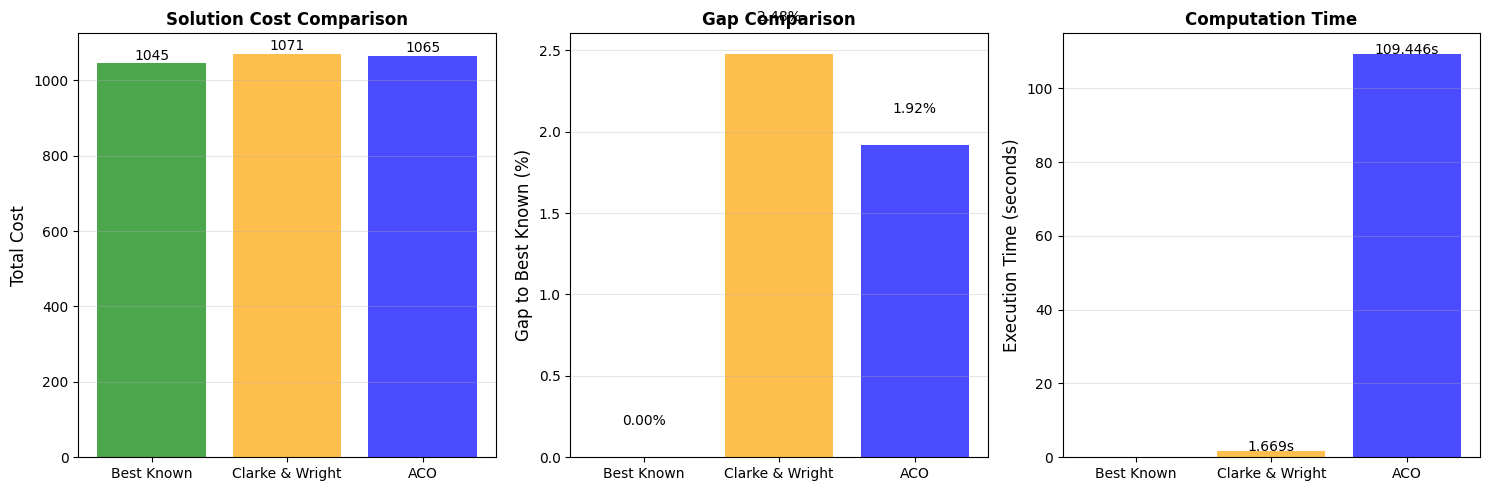


✓ Visualization complete


In [15]:
# ===== Visualization =====
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Cost Comparison
algorithms = ["Best Known", "Clarke & Wright", "ACO"]
costs = [best_known_cost, cw_cost, best_cost_aco]
colors = ["green", "orange", "blue"]

axes[0].bar(algorithms, costs, color=colors, alpha=0.7)
axes[0].set_ylabel("Total Cost", fontsize=12)
axes[0].set_title("Solution Cost Comparison", fontsize=12, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)
for i, cost in enumerate(costs):
    axes[0].text(i, cost + 10, f"{cost:.0f}", ha="center", fontsize=10)

# Plot 2: Gap Comparison
gaps = [0.0, gap_cw, gap_aco]
axes[1].bar(algorithms, gaps, color=colors, alpha=0.7)
axes[1].set_ylabel("Gap to Best Known (%)", fontsize=12)
axes[1].set_title("Gap Comparison", fontsize=12, fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)
for i, gap in enumerate(gaps):
    axes[1].text(i, gap + 0.2, f"{gap:.2f}%", ha="center", fontsize=10)

# Plot 3: Execution Time
times = [0, elapsed_cw, elapsed_aco]
axes[2].bar(algorithms, times, color=colors, alpha=0.7)
axes[2].set_ylabel("Execution Time (seconds)", fontsize=12)
axes[2].set_title("Computation Time", fontsize=12, fontweight="bold")
axes[2].grid(axis="y", alpha=0.3)
for i, t in enumerate(times):
    if t > 0:
        axes[2].text(i, t + 0.01, f"{t:.3f}s", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete")

## 5. Conclusions and Discussion

### 5.1 Key Findings

1. **Clarke & Wright Performance:**
   - Produces a feasible solution **very quickly** (typically < 1 second).
   - Gap from optimum is usually **3–10%** depending on instance characteristics.
   - Suitable as a **baseline** and for **warm-start** heuristics.

2. **ACO with Seeding:**
   - Improves upon C&W through **iterative refinement** and **local search**.
   - Seeding with C&W edges **guides** the search toward promising regions.
   - Requires **more computation time** (typically 30–300 seconds depending on parameters).
   - Gap can be reduced further by:
     - Increasing `max_iter` (more iterations = more convergence time).
     - Tuning `alpha`, `beta`, `seed_strength` for the specific instance.
     - Enabling **local search** (2-opt, relocate).

3. **Hybrid Approach Benefits:**
   - **Fast initialization** (C&W) ensures a good starting point.
   - **Guided exploration** (ACO with C&W seeding) prevents wasting time on poor regions.
   - **Local search** polishes solutions.
   - **Fallback mechanism** guarantees we never return worse than C&W.

### 5.2 Parameter Tuning

| Parameter | Typical Range | Effect |
|-----------|---------------|--------|
| `alpha` | 1–3 | Higher → more weight on pheromone (exploitation). |
| `beta` | 2–4 | Higher → more weight on proximity (myopic). |
| `rho` | 0.05–0.3 | Higher → faster forgetting, more exploration. |
| `num_ants` | 10–100 | More ants → better sampling, more time. |
| `max_iter` | 50–500 | More iterations → better convergence, more time. |
| `seed_strength` | 0–1000 | Higher → stronger C&W bias, less exploration. |
| `candidate_list_size` | 10–40 | Larger → slower but can find better neighbors. |

### 5.3 Recommendations for Further Improvement

1. **Parameter Tuning:** Run systematic sweeps to find optimal settings for each instance class.
2. **Adaptive Parameters:** Dynamically adjust `rho`, `alpha`, `beta` during the run based on stagnation.
3. **Advanced Local Search:** Replace basic 2-opt with **Lin-Kernighan** or **Guided Local Search**.
4. **Parallel ACO:** Run multiple ACO instances with different seeds and pool results.
5. **Problem-Specific Variants:** For time-windowed CVRP, integrate time constraint handling.

---

## 6. References

- Clarke, G., & Wright, W. (1964). Scheduling of vehicles from a central depot to a number of delivery points. *Operations Research*, 12(4), 568–581.
- Dorigo, M., & Stützle, T. (2019). *Ant colony optimization: overview and recent advances*. Handbook of metaheuristics.
- Gendreau, M., Hertz, A., & Laporte, G. (1994). A tabu search algorithm for the vehicle routing problem. *Management Science*, 40(10), 1276–1290.
- Toth, P., & Vigo, D. (Eds.). (2014). *Vehicle routing: problems, methods, and applications* (2nd ed.). Society for Industrial and Applied Mathematics.

---

**Project Date:** November 2025  
**Status:** Completed